## Identify potential extreme rainfall events from GloFAS reforecast data

- Read in data from 2003 to 2023 
- 10 ensemble members per forecast
- Forecasts run every 2-3 days on average 
- Lead time T+0 through to T+240 (10-day)

In [1]:
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import logging
from pathlib import Path
import time

### Open a single month (August 2015) to produce a time-series plot of the ensemble members

- Save the GRIB file as an nc file for faster processing 
- Read in and produce a time-series plot 

In [37]:
file_path = '/mnt/metdata/W25-2348/glofas/ensemble_reforecasts/2015/cems-glofas-reforecast_2015_hmonth08/data.grib'
output_path = '/mnt/metdata/W25-2348/glofas/processed_ensemble_members/glofas_reforecast_2015_08.nc'
dsf = xr.open_dataset(file_path, engine='cfgrib', backend_kwargs={"indexpath": ""})
encoding = {var: {"zlib": True, "complevel": 4} for var in dsf.data_vars}
dsf.to_netcdf(output_path, format="NETCDF4", encoding=encoding)

In [41]:
glofas_reforecast_ds = xr.open_dataset(output_path)
glofas_da = glofas_reforecast_ds['dis24'].sel(latitude=53.375,method='nearest').sel(longitude=353.625,method='nearest')
glofas_da = glofas_da.sel(time='2015-08-22')

### Produce time series plot from the reforecast initialised on 22 August 2015

- The event flagged by our analysis occurred on 25 August (T+72)

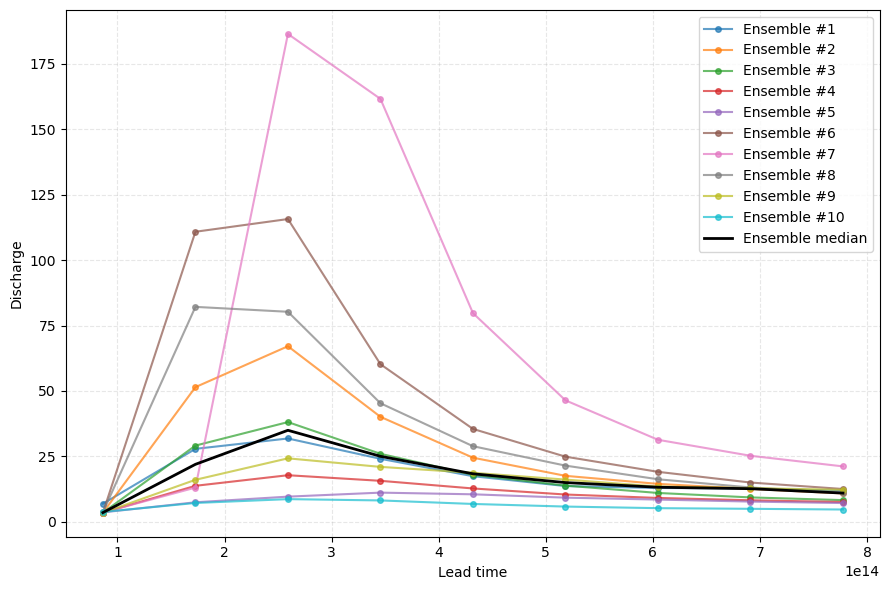

In [46]:
fig, ax = plt.subplots(figsize=(9,6))
members = [1,2,3,4,5,6,7,8,9,10]

# if dask-backed, compute once (brings only small array into memory: n_members x n_steps)
if hasattr(glofas_da.data, "compute"):
    glofas_da = glofas_da.compute()

steps = glofas_da['step'].values        # x-axis values
nums = glofas_da['number'].values       # ensemble member ids
data = glofas_da.values                 # shape (n_members, n_steps)

# plot each member; label only the first (or a subset) to avoid clutter
for i, num in enumerate(nums):
    lbl = f"Ensemble #{num}"# if i == 0 else None   # only label the first (change as needed)
    ax.plot(steps, data[i], linestyle='-', marker='o', ms=4, alpha=0.7, label=lbl)

# optionally plot ensemble median and 25-75% band
median = np.median(data, axis=0)
p25 = np.percentile(data, 25, axis=0)
p75 = np.percentile(data, 75, axis=0)
ax.plot(steps, median, color='k', lw=2, label='Ensemble median')
# ax.fill_between(steps, p25, p75, color='gray', alpha=0.25, label='25-75%')

# add background grid 
ax.grid(True, linestyle='--', alpha=0.3)

ax.set_xlabel('Lead time')
ax.set_ylabel('Discharge')
ax.legend()
plt.tight_layout()
plt.savefig(f'/mnt/metdata/W25-2348/glofas/processed_ensemble_members/ensemble_spread_20150822.png', dpi=300)

### Did surrounding forecasts have similar levels of uncertainty? 

In [52]:
glofas_reforecast_ds = xr.open_dataset(output_path)
glofas_da = glofas_reforecast_ds['dis24'].sel(latitude=53.375,method='nearest').sel(longitude=353.625,method='nearest')
glofas_da = glofas_da.sel(time='2015-08-19')

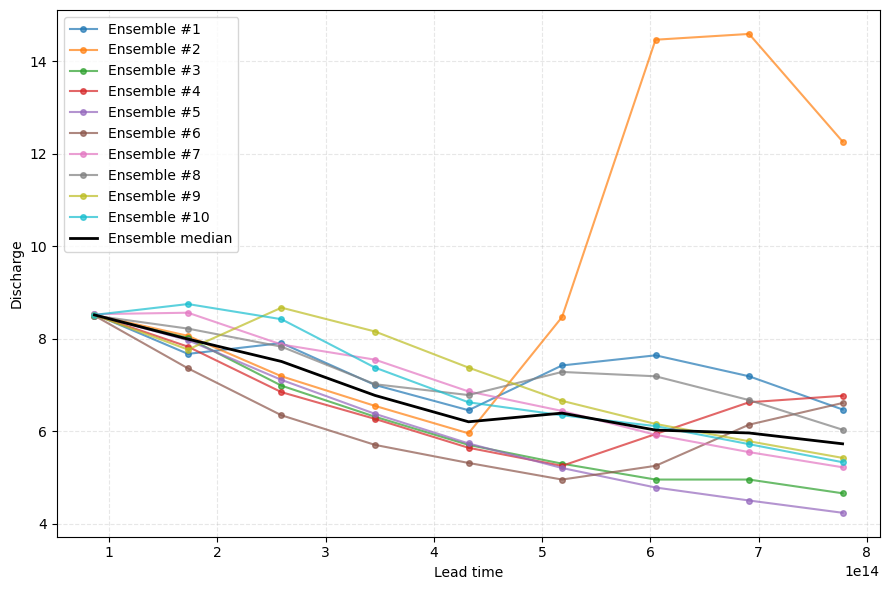

In [ ]:
fig, ax = plt.subplots(figsize=(9,6))
members = [1,2,3,4,5,6,7,8,9,10]

# if dask-backed, compute once (brings only small array into memory: n_members x n_steps)
if hasattr(glofas_da.data, "compute"):
    glofas_da = glofas_da.compute()

steps = glofas_da['step'].values        # x-axis values
nums = glofas_da['number'].values       # ensemble member ids
data = glofas_da.values                 # shape (n_members, n_steps)

# plot each member; label only the first (or a subset) to avoid clutter
for i, num in enumerate(nums):
    lbl = f"Ensemble #{num}"# if i == 0 else None   # only label the first (change as needed)
    ax.plot(steps, data[i], linestyle='-', marker='o', ms=4, alpha=0.7, label=lbl)

# optionally plot ensemble median and 25-75% band
median = np.median(data, axis=0)
p25 = np.percentile(data, 25, axis=0)
p75 = np.percentile(data, 75, axis=0)
ax.plot(steps, median, color='k', lw=2, label='Ensemble median')
# ax.fill_between(steps, p25, p75, color='gray', alpha=0.25, label='25-75%')

# add background grid 
ax.grid(True, linestyle='--', alpha=0.3)

ax.set_xlabel('Lead time')
ax.set_ylabel('Discharge')
ax.legend()
plt.tight_layout()
plt.savefig(f'/mnt/metdata/W25-2348/glofas/processed_ensemble_members/ensemble_spread_20150819.png', dpi=300)